In [1]:
from BitcoinLLMQA_utils import (
    fetch_bitcoin_price,
    update_dataset,
    analyze_data,
    load_dataset,
    visualize_bitcoin_data,
    get_price_trends
)

import pandas as pd
import matplotlib.pyplot as plt
import requests

## Demonstrate CoinGecko API (Raw vs Wrapper)

In [2]:
response = requests.get("https://api.coingecko.com/api/v3/simple/price?ids=bitcoin&vs_currencies=usd", timeout=10)
raw_data = response.json()
print("Direct CoinGecko API call:")
print(f"Response: {raw_data}")
print(f"Bitcoin price: ${raw_data['bitcoin']['usd']:,.2f}\n")

# Show wrapper function
print("Using our wrapper function:")
btc_price = fetch_bitcoin_price()
print(f"Bitcoin price: ${btc_price:,.2f}")

Direct CoinGecko API call:
Response: {'bitcoin': {'usd': 102761}}
Bitcoin price: $102,761.00

Using our wrapper function:
Bitcoin price: $102,761.00


# Demonstrate dataset update

In [3]:
print("Updating dataset with current price...")
df = update_dataset(btc_price)
print("\nMost recent entries:")
display(df.tail(5))

Updating dataset with current price...
Saved price: 102761 | Volatility: 0.0011759067396684103

Most recent entries:


,timestamp,price,volatility
604,2025-04-24 18:22:58,93497,0.001136
605,2025-04-24 18:27:58,93530,0.00113
606,2025-04-24 18:32:58,93567,0.001082
607,2025-04-24 18:37:59,93607,0.001038
608,2025-04-24 18:42:59,93577,0.001176


# Load and visualize historical data

Loading complete dataset...
Dataset contains 609 records


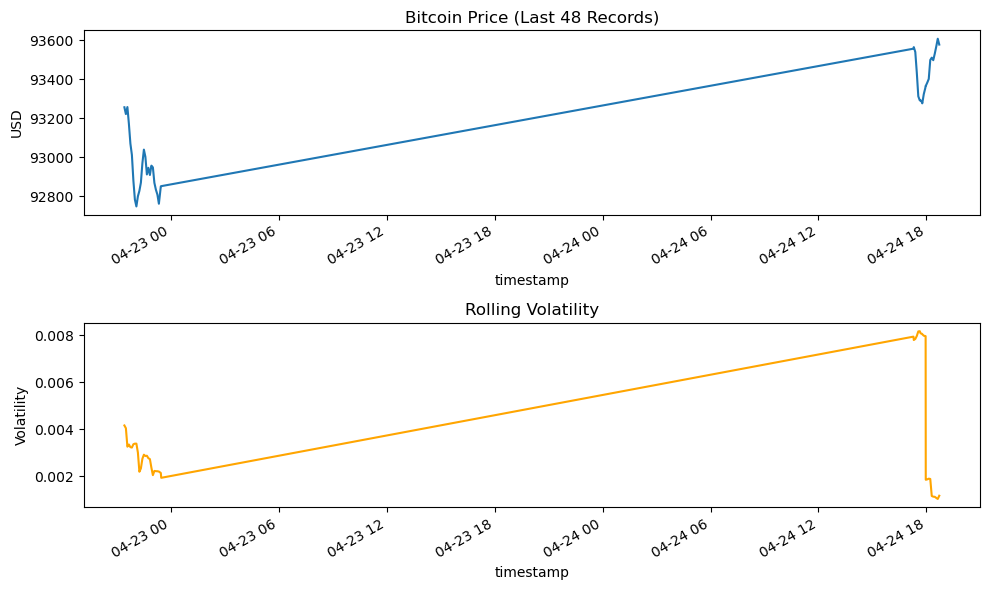

In [4]:
print("Loading complete dataset...")
complete_df = load_dataset()
print(f"Dataset contains {len(complete_df)} records")

# Generate visualization
fig = visualize_bitcoin_data(complete_df)
plt.show()

# Demonstrate analysis functions

In [5]:
# Get price trend analysis
print("Price trends:")
trends = get_price_trends(complete_df, period='24h')
for key, value in trends.items():
    if key == 'pct_change':
        print(f"{key}: {value:.2f}%")
    elif 'price' in key:
        print(f"{key}: ${value:,.2f}")
    else:
        print(f"{key}: {value}")

# Generate metrics
print("\nGenerating dataset metrics...")
metrics = analyze_data(complete_df)

print("\nHourly averages:")
display(metrics['hourly_avg'].tail(3))

print("\nVolatility anomalies:")
if len(metrics['recent_anomalies']) > 0:
    display(metrics['recent_anomalies'].tail(3))
else:
    print("No recent volatility anomalies detected")

Price trends:
error: Not enough data points for the selected period

Generating dataset metrics...

Hourly averages:


,price,volatility
timestamp,,
2025-04-24 16:00:00,NaN,NaN
2025-04-24 17:00:00,93381.000000,0.007521
2025-04-24 18:00:00,93507.666667,0.001376



Volatility anomalies:


,timestamp,price,volatility
527,2025-04-22 18:34:05,92938,0.010163
529,2025-04-22 18:44:06,92762,0.010303
530,2025-04-22 18:49:06,92754,0.010088


# Summary

In [6]:
print("\nAPI Integration Summary:")
print("1. CoinGecko API provides real-time Bitcoin price data")
print("2. Our wrapper functions simplify data fetching, storage and analysis")
print("3. Datasets are stored with timestamps in CSV format")
print("4. Advanced metrics include volatility calculation and anomaly detection")


API Integration Summary:
1. CoinGecko API provides real-time Bitcoin price data
2. Our wrapper functions simplify data fetching, storage and analysis
3. Datasets are stored with timestamps in CSV format
4. Advanced metrics include volatility calculation and anomaly detection
